# CF-GMEL-GBRT: Counterfactual Edge Perturbations for Urban Mobility Flow

**Mirrors the CF-GNNExplainer pipeline** — but for GMEL+GBRT.

**Workflow:**
1. Pick an OD pair and get its predicted flow class (Low / Medium / High)
2. Extract the k-hop neighbourhood of the origin and destination census tracts
3. For each edge in that subgraph: try **removing** it
4. For each missing edge in that subgraph: try **adding** it
5. After each perturbation, rebuild the DGL graph → re-run GMEL → GBRT → discretise
6. Record perturbations that flip the flow class (counterfactuals)
7. Visualise before/after subgraph (removed = dashed red, added = green)

**Key difference from node-feature CF:**
We are changing *who is connected to whom* in the census-tract adjacency graph, not the attributes of nodes.

## 1. Imports

In [1]:
import os, sys, pickle, warnings
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if Path('code/utils.py').exists():
    os.chdir('code')

import utils
from model import MyModel

warnings.filterwarnings('ignore')
print('Imports OK | cwd:', Path.cwd())

Imports OK | cwd: /Users/kazishahrukhomar/Documents/MISC/GMEL/code


## 2. Config

In [2]:
YEAR              = 2015
NUM_HIDDEN_LAYERS = 1
EMBEDDING_SIZE    = 128
MULTITASK_WEIGHTS = (0.5, 0.25, 0.25)
DEVICE            = 'cpu'
device            = torch.device(DEVICE)

# ── OD pair to explain ────────────────────────────────────────────────────────
SRC_NODE = 25
DST_NODE = 19
# ─────────────────────────────────────────────────────────────────────────────

# k-hop neighbourhood to search for edge perturbations (same as CF-GNNExplainer)
N_HOPS = 2

print(f'OD pair : {SRC_NODE} → {DST_NODE}')
print(f'k-hops  : {N_HOPS}')

OD pair : 25 → 19
k-hops  : 2


## 3. Load Data, GMEL, and GBRT

In [3]:
data           = utils.load_dataset(year=YEAR)
ct_adj_orig    = data['ct_adjacency_withweight'].copy()   # (2168,2168), min-max scaled
node_feats     = data['node_feats']                       # z-score normalised (2168,65)
distm          = data['distm']
num_nodes      = data['num_nodes']
MEAN_EDGE_W    = ct_adj_orig[ct_adj_orig > 0].mean()      # used when adding new edges

print(f'Nodes            : {num_nodes}')
print(f'Existing edges   : {int(np.count_nonzero(ct_adj_orig))} directed '
      f'({int(np.count_nonzero(ct_adj_orig))//2} undirected)')
print(f'Avg degree       : {(ct_adj_orig>0).sum(1).mean():.2f}')
print(f'Mean edge weight : {MEAN_EDGE_W:.4f}')

Nodes            : 2168
Existing edges   : 13914 directed (6957 undirected)
Avg degree       : 6.42
Mean edge weight : 0.0644


In [4]:
# GMEL model
g = utils.build_graph_from_matrix(
    ct_adj_orig, node_feats.astype(np.float32), device='cpu'
).to(device)

ckpt_path = (
    f'./models/model_state_layers{NUM_HIDDEN_LAYERS}'
    f'_emb{EMBEDDING_SIZE}_multitask{MULTITASK_WEIGHTS}.pth'
)
model = MyModel(
    g=g, num_nodes=num_nodes,
    in_dim=node_feats.shape[1],
    h_dim=EMBEDDING_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    device=str(device), reg_param=0
).to(device)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print('GMEL loaded:', ckpt_path)

# GBRT
gbrt_path = (
    f'./models/gbrt_year{YEAR}_layers{NUM_HIDDEN_LAYERS}'
    f'_emb{EMBEDDING_SIZE}_multitask{MULTITASK_WEIGHTS}.pkl'
)
with open(gbrt_path, 'rb') as f:
    gbrt = pickle.load(f)
print('GBRT loaded:', gbrt_path)

# Base embeddings
emb_path = (
    f'./embeddings/censustract_embeddings_year{YEAR}'
    f'_layers{NUM_HIDDEN_LAYERS}_emb{EMBEDDING_SIZE}_multitask{MULTITASK_WEIGHTS}.npz'
)
z = np.load(emb_path)
src_emb_base, dst_emb_base = z['arr_0'], z['arr_1']
scaled_distm_base = distm / distm.max() * np.max([src_emb_base.max(), dst_emb_base.max()])
print('Base embeddings loaded:', emb_path)

GMEL loaded: ./models/model_state_layers1_emb128_multitask(0.5, 0.25, 0.25).pth
GBRT loaded: ./models/gbrt_year2015_layers1_emb128_multitask(0.5, 0.25, 0.25).pkl
Base embeddings loaded: ./embeddings/censustract_embeddings_year2015_layers1_emb128_multitask(0.5, 0.25, 0.25).npz


## 4. Discretise Flow — Low / Medium / High

In [5]:
train_od     = data['train'][:, :2].astype(int)
X_train      = np.concatenate([
    src_emb_base[train_od[:, 0]],
    dst_emb_base[train_od[:, 1]],
    scaled_distm_base[train_od[:, 0], train_od[:, 1]].reshape(-1, 1)
], axis=1)
y_train_pred = gbrt.predict(X_train)

LOW_THR      = np.percentile(y_train_pred, 33)
HIGH_THR     = np.percentile(y_train_pred, 67)
CLASS_NAMES  = {0: 'Low', 1: 'Medium', 2: 'High'}
CLASS_COLORS = {0: '#4393c3', 1: '#f4a582', 2: '#d6604d'}

def discretize(flow: float) -> int:
    if flow < LOW_THR:  return 0
    if flow < HIGH_THR: return 1
    return 2

print(f'Low  : flow < {LOW_THR:.2f}')
print(f'Med  : {LOW_THR:.2f} ≤ flow < {HIGH_THR:.2f}')
print(f'High : flow ≥ {HIGH_THR:.2f}')

Low  : flow < 2.68
Med  : 2.68 ≤ flow < 5.36
High : flow ≥ 5.36


## 5. Helper Functions

In [6]:
def get_k_hop_nodes(center_nodes, adj, k):
    """BFS to collect all nodes within k hops of any node in center_nodes."""
    visited = set(center_nodes)
    frontier = set(center_nodes)
    for _ in range(k):
        next_frontier = set()
        for n in frontier:
            neighbours = np.where(adj[n] > 0)[0]
            for nb in neighbours:
                if nb not in visited:
                    visited.add(nb)
                    next_frontier.add(nb)
        frontier = next_frontier
    return sorted(visited)


def get_embeddings(adj_mod):
    """Rebuild DGL graph with a modified adjacency and run GMEL."""
    g_mod = utils.build_graph_from_matrix(
        adj_mod, node_feats.astype(np.float32), device='cpu'
    ).to(device)
    with torch.no_grad():
        se = model(g_mod).detach().cpu().numpy()
        de = model.forward2(g_mod).detach().cpu().numpy()
    sd = distm / distm.max() * np.max([se.max(), de.max()])
    return se, de, sd


def predict_flow(src, dst, se, de, sd):
    """GBRT prediction for one OD pair."""
    X = np.concatenate([se[[src]], de[[dst]], sd[src, dst].reshape(1, 1)], axis=1)
    return float(gbrt.predict(X)[0])


print('Helpers defined.')

Helpers defined.


## 6. Original Prediction

In [7]:
flow_orig  = predict_flow(SRC_NODE, DST_NODE, src_emb_base, dst_emb_base, scaled_distm_base)
class_orig = discretize(flow_orig)

print('=' * 40)
print(f'OD pair        : {SRC_NODE} → {DST_NODE}')
print(f'Predicted flow : {flow_orig:.2f} trips')
print(f'Flow class     : {CLASS_NAMES[class_orig]} (class {class_orig})')
print('=' * 40)

OD pair        : 25 → 19
Predicted flow : 71.41 trips
Flow class     : High (class 2)


## 7. Extract k-hop Subgraph

We search for edge perturbations only within the combined k-hop neighbourhood of **both** the origin and destination nodes — exactly as CF-GNNExplainer does with its subgraph.

In [8]:
subgraph_nodes = get_k_hop_nodes([SRC_NODE, DST_NODE], ct_adj_orig, N_HOPS)
subgraph_set   = set(subgraph_nodes)
N_SUB          = len(subgraph_nodes)

print(f'Subgraph nodes ({N_HOPS}-hop around {SRC_NODE} and {DST_NODE}): {N_SUB}')

# All candidate edge pairs (i, j) with i < j, both in subgraph
sub_arr = sorted(subgraph_set)
candidate_pairs = [
    (sub_arr[i], sub_arr[j])
    for i in range(len(sub_arr))
    for j in range(i + 1, len(sub_arr))
]

# Split into remove (edge exists) and add (edge absent)
pairs_to_remove = [(i, j) for (i, j) in candidate_pairs if ct_adj_orig[i, j] > 0]
pairs_to_add    = [(i, j) for (i, j) in candidate_pairs if ct_adj_orig[i, j] == 0]

print(f'Candidate edges to REMOVE : {len(pairs_to_remove)}')
print(f'Candidate edges to ADD    : {len(pairs_to_add)}')
print(f'Total perturbations to try: {len(pairs_to_remove) + len(pairs_to_add)}')

Subgraph nodes (2-hop around 25 and 19): 53
Candidate edges to REMOVE : 136
Candidate edges to ADD    : 1242
Total perturbations to try: 1378


## 8. Counterfactual Edge Search

For each candidate edge perturbation (add or remove), we:
1. Modify `ct_adj` in-place (symmetric — census-tract adjacency is undirected)
2. Rebuild the DGL graph
3. Run GMEL → new embeddings
4. GBRT → new flow → discretise
5. If class flips → record as a counterfactual
6. Restore `ct_adj` for the next iteration

In [9]:
from tqdm import tqdm

cf_records = []
adj_work   = ct_adj_orig.copy()

all_perturbations = (
    [('remove', i, j) for (i, j) in pairs_to_remove] +
    [('add',    i, j) for (i, j) in pairs_to_add]
)

for action, i, j in tqdm(all_perturbations, desc='CF edge search'):
    orig_weight = adj_work[i, j]

    # Apply perturbation (symmetric)
    if action == 'remove':
        adj_work[i, j] = adj_work[j, i] = 0.0
    else:
        adj_work[i, j] = adj_work[j, i] = MEAN_EDGE_W

    # GMEL + GBRT
    se_cf, de_cf, sd_cf = get_embeddings(adj_work)
    flow_cf  = predict_flow(SRC_NODE, DST_NODE, se_cf, de_cf, sd_cf)
    class_cf = discretize(flow_cf)

    if class_cf != class_orig:
        cf_records.append({
            'action'         : action,
            'node_i'         : i,
            'node_j'         : j,
            'orig_weight'    : round(orig_weight, 4),
            'new_weight'     : round(adj_work[i, j], 4),
            'flow_orig'      : round(flow_orig, 3),
            'flow_cf'        : round(flow_cf, 3),
            'class_orig'     : class_orig,
            'class_cf'       : class_cf,
            'class_orig_name': CLASS_NAMES[class_orig],
            'class_cf_name'  : CLASS_NAMES[class_cf],
        })

    # Restore
    adj_work[i, j] = adj_work[j, i] = orig_weight

print(f'\nDone. {len(cf_records)} counterfactual edge perturbations found.')

CF edge search: 100%|██████████| 1378/1378 [02:24<00:00,  9.56it/s]


Done. 0 counterfactual edge perturbations found.


## 9. Results Table

In [10]:
if not cf_records:
    print('No CFs found. Try increasing N_HOPS or pick a different OD pair.')
else:
    df_cf = pd.DataFrame(cf_records)

    # Flow change magnitude — smaller = more minimal perturbation
    df_cf['flow_change'] = (df_cf['flow_cf'] - df_cf['flow_orig']).abs()
    df_cf = df_cf.sort_values(['class_cf_name', 'action', 'flow_change'])

    display(df_cf[[
        'action', 'node_i', 'node_j',
        'orig_weight', 'new_weight',
        'flow_orig', 'flow_cf',
        'class_orig_name', 'class_cf_name'
    ]].rename(columns={
        'action'         : 'Action',
        'node_i'         : 'Node i',
        'node_j'         : 'Node j',
        'orig_weight'    : 'Weight (orig)',
        'new_weight'     : 'Weight (CF)',
        'flow_orig'      : 'Flow (orig)',
        'flow_cf'        : 'Flow (CF)',
        'class_orig_name': 'Class (orig)',
        'class_cf_name'  : 'Class (CF)',
    }))

No CFs found. Try increasing N_HOPS or pick a different OD pair.


## 10. Visualise — Subgraph Before and After Perturbation

Pick the **single best CF** (largest flow change) and draw the subgraph:
- **Dashed red** = removed edge
- **Green** = added edge
- **Red node** = origin (SRC_NODE)
- **Orange node** = destination (DST_NODE)

In [11]:
if cf_records:
    # Best CF = largest flow change (most decisive flip)
    best = df_cf.iloc[df_cf['flow_change'].argmax()]
    bi, bj = int(best['node_i']), int(best['node_j'])
    b_action = best['action']

    print(f'Best CF: {b_action.upper()} edge ({bi}, {bj})')
    print(f'  Flow : {best["flow_orig"]:.2f} → {best["flow_cf"]:.2f}  '
          f'({best["class_orig_name"]} → {best["class_cf_name"]})')

    # Build subgraph adjacency for visualisation
    sub_nodes = subgraph_nodes
    node2idx  = {n: k for k, n in enumerate(sub_nodes)}
    N_s       = len(sub_nodes)
    sub_adj_orig = np.zeros((N_s, N_s))
    for a in range(N_s):
        for b in range(N_s):
            sub_adj_orig[a, b] = ct_adj_orig[sub_nodes[a], sub_nodes[b]]

    sub_adj_cf = sub_adj_orig.copy()
    ii, jj = node2idx[bi], node2idx[bj]
    if b_action == 'remove':
        sub_adj_cf[ii, jj] = sub_adj_cf[jj, ii] = 0.0
    else:
        sub_adj_cf[ii, jj] = sub_adj_cf[jj, ii] = MEAN_EDGE_W

    G_orig = nx.from_numpy_array(sub_adj_orig)
    G_cf   = nx.from_numpy_array(sub_adj_cf)

    src_idx = node2idx[SRC_NODE]
    dst_idx = node2idx[DST_NODE]

    def node_color(k):
        if k == src_idx: return 'red'
        if k == dst_idx: return 'orange'
        return 'steelblue'

    node_colors = [node_color(k) for k in range(N_s)]
    pos = nx.spring_layout(G_orig, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- Left: original subgraph ---
    nx.draw_networkx(
        G_orig, pos=pos, ax=axes[0],
        node_color=node_colors, node_size=150,
        with_labels=True, labels={k: sub_nodes[k] for k in range(N_s)},
        font_size=6, edge_color='gray', alpha=0.85
    )
    axes[0].set_title(
        f'Original subgraph\n'
        f'Flow {SRC_NODE}→{DST_NODE}: {best["flow_orig"]:.1f} ({best["class_orig_name"]})',
        fontsize=11
    )
    axes[0].axis('off')

    # --- Right: counterfactual subgraph ---
    unchanged_edges = [
        (u, v) for (u, v) in G_cf.edges
        if G_orig.has_edge(u, v)
        and not (set([u, v]) == set([ii, jj]))
    ]
    removed_edges = [(ii, jj)] if b_action == 'remove' else []
    added_edges   = [(ii, jj)] if b_action == 'add'    else []

    nx.draw_networkx_nodes(G_cf, pos=pos, ax=axes[1],
                           node_color=node_colors, node_size=150, alpha=0.85)
    nx.draw_networkx_labels(G_cf, pos=pos, ax=axes[1],
                            labels={k: sub_nodes[k] for k in range(N_s)}, font_size=6)
    nx.draw_networkx_edges(G_cf, pos=pos, ax=axes[1],
                           edgelist=unchanged_edges,
                           edge_color='gray', alpha=0.7)
    if removed_edges:
        nx.draw_networkx_edges(G_orig, pos=pos, ax=axes[1],
                               edgelist=removed_edges,
                               edge_color='red', style='dashed', width=2.5, alpha=0.9)
    if added_edges:
        nx.draw_networkx_edges(G_cf, pos=pos, ax=axes[1],
                               edgelist=added_edges,
                               edge_color='green', width=2.5, alpha=0.9)

    action_label = (
        f'Removed edge ({bi}–{bj}) [dashed red]'
        if b_action == 'remove'
        else f'Added edge ({bi}–{bj}) [green]'
    )
    axes[1].set_title(
        f'Counterfactual subgraph\n'
        f'Flow {SRC_NODE}→{DST_NODE}: {best["flow_cf"]:.1f} ({best["class_cf_name"]})\n'
        f'{action_label}',
        fontsize=11
    )
    axes[1].axis('off')

    legend = [
        mpatches.Patch(color='red',       label=f'Origin  (node {SRC_NODE})'),
        mpatches.Patch(color='orange',    label=f'Dest    (node {DST_NODE})'),
        mpatches.Patch(color='steelblue', label='Other nodes'),
    ]
    axes[1].legend(handles=legend, fontsize=8, loc='lower right')

    plt.suptitle(
        f'CF-GMEL-GBRT  |  OD pair {SRC_NODE}→{DST_NODE}  |  {N_HOPS}-hop subgraph',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()

## 11. Summary — All CFs by Action Type

In [12]:
if cf_records:
    summary = df_cf.groupby(['action', 'class_cf_name']).size().reset_index(name='count')
    print('CF count by action and target class:')
    print(summary.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 4))
    colors  = [CLASS_COLORS[c] for c in df_cf['class_cf'].values]
    actions = df_cf['action'].values

    for k, (_, row) in enumerate(df_cf.iterrows()):
        marker = 'X' if row['action'] == 'remove' else 'o'
        ax.scatter(k, row['flow_cf'], color=CLASS_COLORS[row['class_cf']],
                   marker=marker, s=80, zorder=3)

    ax.axhline(flow_orig, color='black', linewidth=1.5, linestyle='--',
               label=f'Original ({flow_orig:.1f})')
    ax.axhspan(0,        LOW_THR,  alpha=0.07, color=CLASS_COLORS[0])
    ax.axhspan(LOW_THR,  HIGH_THR, alpha=0.07, color=CLASS_COLORS[1])
    ax.axhspan(HIGH_THR, max(HIGH_THR * 1.5, df_cf['flow_cf'].max() * 1.1),
               alpha=0.07, color=CLASS_COLORS[2])

    ax.set_xlabel('CF index', fontsize=10)
    ax.set_ylabel('Predicted flow after perturbation', fontsize=10)
    ax.set_title(f'All CF flows  |  OD {SRC_NODE}→{DST_NODE}  (✕=remove, ●=add)', fontsize=11)

    legend_patches = [
        mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c]) for c in CLASS_NAMES
    ] + [plt.Line2D([0], [0], color='black', linestyle='--', label='Original flow')]
    ax.legend(handles=legend_patches, fontsize=8)
    plt.tight_layout()
    plt.show()

## 12. Scan Multiple OD Pairs (optional)

Run the edge CF search over several test pairs and report how often each edge shows up as a counterfactual — revealing structurally important connections in the transport network.

In [13]:
N_PAIRS_TO_SCAN = 5    # increase for broader coverage (slow: N_HOPS^2 * edges per pair)
test_pairs      = data['test'][:N_PAIRS_TO_SCAN, :2].astype(int)

scan_records = []

for pair_idx, (src, dst) in enumerate(test_pairs):
    src, dst = int(src), int(dst)
    f0 = predict_flow(src, dst, src_emb_base, dst_emb_base, scaled_distm_base)
    c0 = discretize(f0)

    sub_nodes = get_k_hop_nodes([src, dst], ct_adj_orig, N_HOPS)
    sub_arr   = sorted(sub_nodes)
    pairs_rm  = [(sub_arr[a], sub_arr[b]) for a in range(len(sub_arr))
                 for b in range(a+1, len(sub_arr)) if ct_adj_orig[sub_arr[a], sub_arr[b]] > 0]
    pairs_add = [(sub_arr[a], sub_arr[b]) for a in range(len(sub_arr))
                 for b in range(a+1, len(sub_arr)) if ct_adj_orig[sub_arr[a], sub_arr[b]] == 0]

    adj_w = ct_adj_orig.copy()
    for action, pairs in [('remove', pairs_rm), ('add', pairs_add)]:
        for (i, j) in pairs:
            ow = adj_w[i, j]
            adj_w[i, j] = adj_w[j, i] = 0.0 if action == 'remove' else MEAN_EDGE_W
            se_cf, de_cf, sd_cf = get_embeddings(adj_w)
            fc = predict_flow(src, dst, se_cf, de_cf, sd_cf)
            cc = discretize(fc)
            if cc != c0:
                scan_records.append({
                    'pair_idx': pair_idx, 'src': src, 'dst': dst,
                    'action': action, 'node_i': i, 'node_j': j,
                    'edge_label': f'({i},{j})',
                    'class_orig': CLASS_NAMES[c0], 'class_cf': CLASS_NAMES[cc],
                })
            adj_w[i, j] = adj_w[j, i] = ow

    print(f'  Pair {pair_idx+1}/{N_PAIRS_TO_SCAN}  {src}→{dst}  orig={CLASS_NAMES[c0]}')

print(f'\nTotal CF edges across {N_PAIRS_TO_SCAN} pairs: {len(scan_records)}')

  Pair 1/5  0→50  orig=High
  Pair 2/5  0→61  orig=High
  Pair 3/5  0→62  orig=Medium
  Pair 4/5  0→76  orig=Low
  Pair 5/5  0→120  orig=High

Total CF edges across 5 pairs: 757


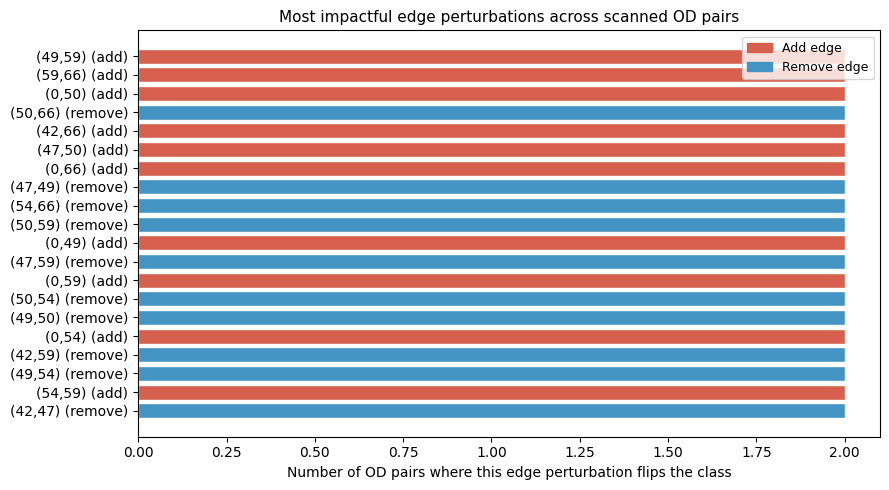

In [14]:
if scan_records:
    df_scan = pd.DataFrame(scan_records)

    edge_counts = (
        df_scan
        .groupby(['edge_label', 'action'])['pair_idx']
        .nunique()
        .reset_index(name='n_pairs')
        .sort_values('n_pairs', ascending=False)
        .head(20)
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    bar_colors = ['#d6604d' if a == 'add' else '#4393c3'
                  for a in edge_counts['action']]
    ax.barh(
        edge_counts['edge_label'] + ' (' + edge_counts['action'] + ')',
        edge_counts['n_pairs'],
        color=bar_colors, edgecolor='white'
    )
    ax.set_xlabel('Number of OD pairs where this edge perturbation flips the class', fontsize=10)
    ax.set_title('Most impactful edge perturbations across scanned OD pairs', fontsize=11)
    legend_patches = [
        mpatches.Patch(color='#d6604d', label='Add edge'),
        mpatches.Patch(color='#4393c3', label='Remove edge'),
    ]
    ax.legend(handles=legend_patches, fontsize=9)
    plt.tight_layout()
    plt.show()